1. RF classifier (RandomizedSearchCV hyperparameter tuning)
2. MS degree centrality percentile 

In [11]:
#LOAD DATA AND PREPROCESSING
import pandas as pd
import numpy as np
import ast

# === STEP 1: LOAD & RENAME ===
data_path = "/home/goel107/NCEMS/ANALYSIS/07_15_2025/20251023-s288c-annotated-PPI-net.pkl"
df = pd.read_pickle(data_path)

# === STEP 2: SUBSET AND CLEAN ===
selected_columns = df[[
    'node', '_wkshell', 'Y2H_wkshell',
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality', 'closeness_centrality',
    'load_centrality', 'pagerank', 'information_centrality',
    'Y2H_degree_centrality', 'Y2H_betweenness_centrality', 'Y2H_eigenvector_centrality',
    'Y2H_closeness_centrality', 'Y2H_load_centrality', 'Y2H_pagerank', 'Y2H_information_centrality',
    'DeepTMHMM_class', 'signalP_trimmed_sequence',
    'IDR_count', 'N_aa_disordered', 'disorder_fraction',
    'is_disordered_0.05', 'is_disordered_0.10', 'is_disordered_0.15', 'is_disordered_0.20', 'is_disordered_0.25', 'is_disordered_0.30', 'is_disordered_0.35', 
    'is_disordered_0.40', 'is_disordered_0.45', 'is_disordered_0.50', 'is_disordered_0.55', 'is_disordered_0.60', 'is_disordered_0.65', 'is_disordered_0.70', 
    'is_disordered_0.75', 'is_disordered_0.80', 'is_disordered_0.85', 'is_disordered_0.90', 'is_disordered_0.95', 'is_disordered_1.00',
    'mean_plddt', 'L', 
    'Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score', 'FoldX_best_total_energy',
    'Christiano_degradation_rate(min-1)', 'Villen_halflife_min',
    'mean_molecules_per_cell', 'median_molecules_per_cell', 'log2_TE',
    'interacting_chaperones', 'in_complex', 'Pfam_Ndomains', 
    'essential',  
    'sequence', 'structure_exists', 'sequence_matches_structure', 'meltome-melting-point', 'meltome-AUC', 'meltome-fit-R2'
       
]].copy()

# Multiply 'cagiada-dG' by -1 (flip sign)
selected_columns['cagiada-dG'] = pd.to_numeric(selected_columns['cagiada-dG'], errors='coerce') * -1

# Replace infinite values with NaN to allow proper cleaning
selected_columns.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fix Pfam_Ndomains: replace empty/NaN with 0
selected_columns['Pfam_Ndomains'] = selected_columns['Pfam_Ndomains'].fillna(0).astype(int)

# === STEP 3: DERIVED FEATURES ===
selected_columns['Length'] = selected_columns['signalP_trimmed_sequence'].fillna('').apply(len)

# Add percentile columns for all centrality metrics
ms_centrality_cols = [
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality',
    'closeness_centrality', 'load_centrality', 'pagerank', 'information_centrality'
]
y2h_centrality_cols = [
    'Y2H_degree_centrality', 'Y2H_betweenness_centrality', 'Y2H_eigenvector_centrality',
    'Y2H_closeness_centrality', 'Y2H_load_centrality', 'Y2H_pagerank', 'Y2H_information_centrality'
]

# Rename MS columns
ms_rename_map = {col: "MS_" + col for col in ms_centrality_cols}
selected_columns.rename(columns=ms_rename_map, inplace=True)

# Add percentiles for MS-based metrics
for col in ms_centrality_cols:
    ms_col = "MS_" + col
    selected_columns[f"{ms_col}_percentile"] = selected_columns[ms_col].rank(pct=True) * 100

# Add percentiles for Y2H-based metrics
for col in y2h_centrality_cols:
    selected_columns[f"{col}_percentile"] = selected_columns[col].rank(pct=True) * 100

# === STEP 4: ONE HOT ENCODING FOR CHAPERONES ===
def fix_list(val):
    if isinstance(val, list):
        return val
    elif isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    elif pd.isnull(val):
        return []
    else:
        return []

selected_columns['interacting_chaperones'] = selected_columns['interacting_chaperones'].apply(fix_list)

def chaperone_category(row):
    node = row['node']
    chaps = row['interacting_chaperones']
    if not chaps or chaps == []:
        return 'protein_is_neither_chaperone_nor_interacts'
    elif node in chaps:
        return 'protein_is_chaperone'
    else:
        return 'protein_interacts_with_chaperone'

selected_columns['chaperone_category'] = selected_columns.apply(chaperone_category, axis=1)
selected_columns['is_chaperone'] = (selected_columns['chaperone_category'] == 'protein_is_chaperone').astype(int)
selected_columns['interacts_with_chaperone'] = (selected_columns['chaperone_category'] == 'protein_interacts_with_chaperone').astype(int)
selected_columns['neither_chaperone_nor_interacts'] = (selected_columns['chaperone_category'] == 'protein_is_neither_chpaerone_nor_interacts').astype(int)

# === STEP 5: Match seq and structure nodes ===
selected_columns.info()
selected_columns = selected_columns[~selected_columns["sequence"].isna()]
print (f"Number of nodes with sequence information: {selected_columns.shape[0]}")

# record those nodes that do not have sequence information
no_seq_nodes = selected_columns[selected_columns["sequence"].isna()]
print (f"Number of nodes without sequence information: {no_seq_nodes.shape[0]}")

# remove nodes with no structure from AF2
selected_columns = selected_columns[selected_columns["structure_exists"] == 1]
print (f"Number of nodes with sequence & structure information: {selected_columns.shape[0]}")

# a small number of nodes have an AF2 structure, but its sequence does not match the sequence information from SGD - we can filter those out as well
selected_columns = selected_columns[selected_columns["sequence_matches_structure"] == True]
print (f"Number of nodes with sequence, structure, and matching information between the two: {selected_columns.shape[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3927 entries, 0 to 3926
Data columns (total 82 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   node                                   3927 non-null   object 
 1   _wkshell                               3927 non-null   int64  
 2   Y2H_wkshell                            1465 non-null   float64
 3   MS_degree_centrality                   3927 non-null   float64
 4   MS_betweenness_centrality              3927 non-null   float64
 5   MS_eigenvector_centrality              3927 non-null   float64
 6   MS_closeness_centrality                3927 non-null   float64
 7   MS_load_centrality                     3927 non-null   float64
 8   MS_pagerank                            3927 non-null   float64
 9   MS_information_centrality              3927 non-null   float64
 10  Y2H_degree_centrality                  1465 non-null   float64
 11  Y2H_

In [12]:
# Filter: Remove low pLDDT and TMD/SP proteins
filtered_df = selected_columns[
    (selected_columns['mean_plddt'] >= 50) &
    (~selected_columns['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()
# Optional: Print stats to verify
print(f"Original rows: {len(selected_columns)}")
print(f"Filtered rows: {len(filtered_df)}")

# Update selected_columns to use the filtered version for downstream codes
selected_columns = filtered_df

Original rows: 3859
Filtered rows: 3209


In [13]:
# SCRIPT 2: Feature & Target Preparation
import pandas as pd
import numpy as np

# Filter nodes to those where sequence matches structure
selected_columns = selected_columns[
    (selected_columns['sequence_matches_structure'] == True)
].copy()

# 1. Create binary target for top 10% MS_degree_centrality
threshold = 100 - 10.0  # 90 percentile cutoff
selected_columns['y_top1p0'] = (
    selected_columns['MS_degree_centrality_percentile'] >= threshold
).astype(int)

# 2. Feature & Target Preparation
ml_features = [
    'Ghosh-Dill-dG', 'cagiada-dG', 'Rosetta_best_total_score',
    'Villen_halflife_min',
    'mean_molecules_per_cell',
    'interacts_with_chaperone', 'in_complex',
    'essential',
    'meltome-melting-point', 'N_aa_disordered', 'disorder_fraction', 'mean_plddt'
]

X = selected_columns[ml_features].copy()
y = selected_columns['y_top1p0'].copy()

# Replace common string indicators of missing values with NaN, then convert to numeric
missing_indicators = [
    'n.d.', 'N.D.', 'nd', 'ND', 'na', 'NA', 'null', 'NULL',
    'missing', 'MISSING', '-', 'n/a', 'N/A', ''
]

for col in ml_features:
    X[col] = X[col].replace(missing_indicators, np.nan)
    X[col] = pd.to_numeric(X[col], errors='coerce')

# --- Optional: Create missingness indicators ---
# missing_features = [col for col in X.columns if X[col].isnull().any()]
# for col in missing_features:
#     X[f"{col}_missing"] = X[col].isnull().astype(int)
# missing_indicator_features = [f"{col}_missing" for col in missing_features]
# ml_features_extended = ml_features + missing_indicator_features

# Fill remaining NaNs with -999 (important for sklearn RF)
X_filled = X.fillna(-999)

print("✅ Data preparation complete")
print(f"Total usable samples: {len(X_filled)}")

✅ Data preparation complete
Total usable samples: 3209


Data split completed:
Training set: 2567 samples
Test set: 642 samples
Training class ratio: 11.6% high PME
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20, 'class_weight': 'balanced'}
Random Forest model trained

Model Performance:
Balanced Accuracy: 0.752
Precision: 0.702
Recall: 0.533
F1-Score: 0.606
ROC-AUC: 0.918

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       567
           1       0.70      0.53      0.61        75

    accuracy                           0.92       642
   macro avg       0.82      0.75      0.78       642
weighted avg       0.91      0.92      0.91       642


Confusion Matrix:
TP: 40, FP: 17, TN: 550, FN: 35
True Positive Rate (Recall): 0.533
False Positive Rate: 0.030

Computing SHAP values...


/tmp/ipykernel_497600/1895357467.py:115: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


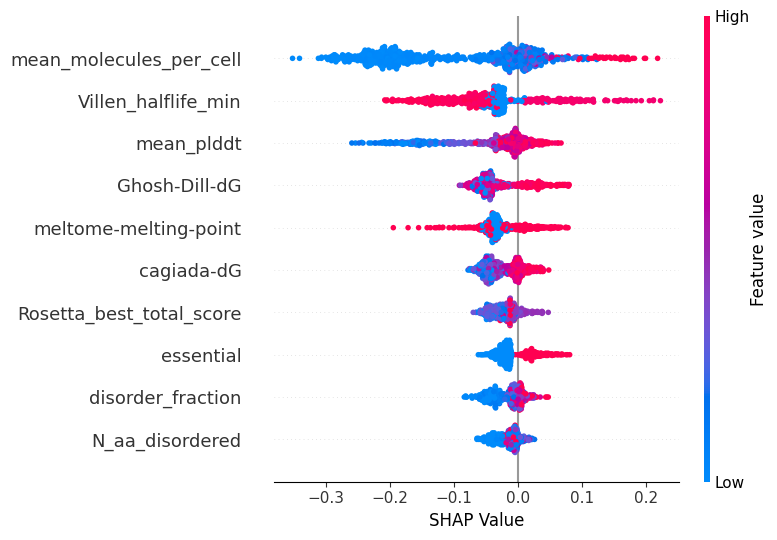


Random Forest Gini-based Feature Importances:
                 Feature  Gini Importance
 mean_molecules_per_cell         0.234116
     Villen_halflife_min         0.156911
              mean_plddt         0.118861
           Ghosh-Dill-dG         0.095601
   meltome-melting-point         0.084259
              cagiada-dG         0.071309
Rosetta_best_total_score         0.065229
         N_aa_disordered         0.054752
       disorder_fraction         0.053588
               essential         0.027349
interacts_with_chaperone         0.019155
              in_complex         0.018872

Generating comprehensive ROC data for Origin plotting...
ROC Data Generated:
Total data points: 85
AUC Score: 0.917672
FPR range: 0.000000 to 1.000000
TPR range: 0.000000 to 1.000000
Threshold range: 0.000000 to inf

Complete ROC Data (Copy-Paste Ready for Origin):
# GPCR PME ROC Curve Data
# False_Positive_Rate	True_Positive_Rate	Threshold	Specificity	Sensitivity	Point_Index	Youden_J	Distance_to_Perfec

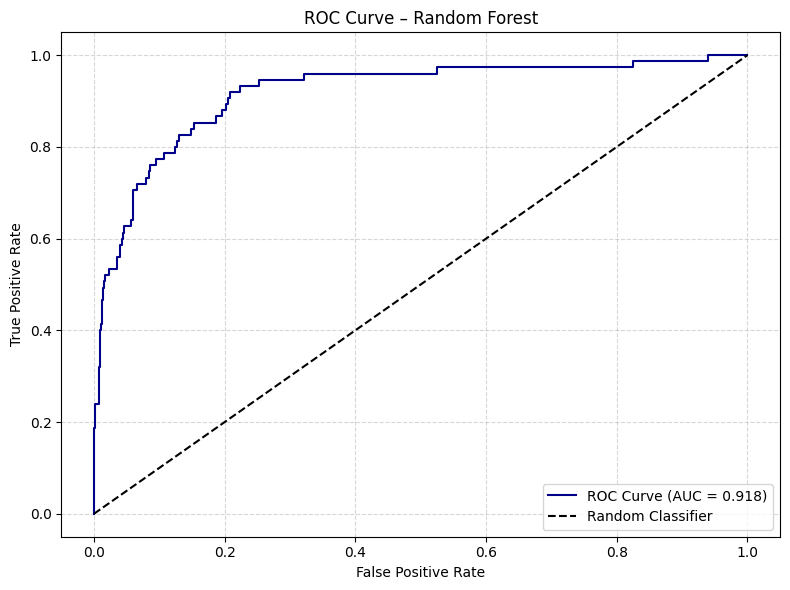

In [14]:
# Version 2: RandomizedSearchCV hyperparameter tuning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

np.random.seed(42)

# -------------------------------------------
# Train-Test Split
# -------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_filled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Data split completed:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training class ratio: {np.mean(y_train)*100:.1f}% high PME")

# -------------------------------------------
# RandomizedSearchCV Parameter Grid
# -------------------------------------------
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced']
}

rf = RandomForestClassifier(random_state=42)

rs = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# -------------------------------------------
# Fit RandomizedSearchCV
# -------------------------------------------
rs.fit(X_train, y_train)

print(f"Best params: {rs.best_params_}")
rf_model = rs.best_estimator_
print("Random Forest model trained")

# -------------------------------------------
# Evaluation
# -------------------------------------------
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

bal_accuracy = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\nModel Performance:")
print(f"Balanced Accuracy: {bal_accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"True Positive Rate (Recall): {tp / (tp + fn):.3f}")
print(f"False Positive Rate: {fp / (fp + tn):.3f}")

# -------------------------------------------
# SHAP Feature Importance
# -------------------------------------------
print("\nComputing SHAP values...")
np.random.seed(42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_class_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_class_values = shap_values[:, :, 1]
else:
    shap_class_values = shap_values

feature_names_list = list(X_filled.columns)
display_names = feature_names_list

plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_class_values,
    X_test,
    feature_names=display_names,
    plot_type='dot',
    max_display=10,
    show=False
)
plt.xlabel('SHAP Value', fontsize=12)
plt.tight_layout()
plt.savefig('SHAP_random_forest1.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

# -------------------------------------------
# Gini Feature Importance
# -------------------------------------------
print("\nRandom Forest Gini-based Feature Importances:")

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': display_names,
    'Gini Importance': importances
}).sort_values(by='Gini Importance', ascending=False)

print(importance_df.to_string(index=False))

# -------------------------------------------
# ROC Data for Origin
# -------------------------------------------
print("\nGenerating comprehensive ROC data for Origin plotting...")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_df = pd.DataFrame({
    'False_Positive_Rate': fpr,
    'True_Positive_Rate': tpr,
    'Threshold': thresholds,
    'Specificity': 1 - fpr,
    'Sensitivity': tpr,
    'Point_Index': range(len(fpr))
})

roc_df['Youden_J'] = roc_df['True_Positive_Rate'] + roc_df['Specificity'] - 1
roc_df['Distance_to_Perfect'] = np.sqrt((fpr - 0)**2 + (tpr - 1)**2)

print("ROC Data Generated:")
print(f"Total data points: {len(roc_df)}")
print(f"AUC Score: {roc_auc:.6f}")
print(f"FPR range: {fpr.min():.6f} to {fpr.max():.6f}")
print(f"TPR range: {tpr.min():.6f} to {tpr.max():.6f}")
print(f"Threshold range: {thresholds.min():.6f} to {thresholds.max():.6f}")

print("\nComplete ROC Data (Copy-Paste Ready for Origin):")
print("# GPCR PME ROC Curve Data")
print("# False_Positive_Rate\tTrue_Positive_Rate\tThreshold\tSpecificity\tSensitivity\tPoint_Index\tYouden_J\tDistance_to_Perfect")

for idx, row in roc_df.iterrows():
    print(
        f"{row['False_Positive_Rate']:.8f}\t"
        f"{row['True_Positive_Rate']:.8f}\t"
        f"{row['Threshold']:.8f}\t"
        f"{row['Specificity']:.8f}\t"
        f"{row['Sensitivity']:.8f}\t"
        f"{row['Point_Index']}\t"
        f"{row['Youden_J']:.8f}\t"
        f"{row['Distance_to_Perfect']:.8f}"
    )

# -------------------------------------------
# ROC Curve Plot
# -------------------------------------------
plt.figure(figsize=(8, 6))
plt.plot(
    roc_df['False_Positive_Rate'],
    roc_df['True_Positive_Rate'],
    label=f'ROC Curve (AUC = {roc_auc:.3f})',
    color='darkblue'
)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
